# Week 3 - Probability Distributions 1 and 2

Learning contents:

1. Frequentist's approach
    - Bernoulli distribution function
    - Maximum Likelihood
    - Display distribution
2. Bayesian approach
    - Binomial distribution
    - Display Binomial distribution for different m
    - Bayesian estimate (posterior mean)
3. Multinomial variables
    - Generate data
    - Frequentist's approach
        - Multinomial Bernoulli distribution function
        - Maximum likelihood
4. Gaussian distribution
    - Distribution function
    - Generate data
    - Display data
    - Frequentist's approach
        - Maximum likelihood
        - Display distribution
    - Bayesian approach
        - Generate data
        - Variance is known, mean is unknown
        - Display mean estimation for different N

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from math import sqrt
from collections import Counter
from scipy.special import comb
from scipy.stats import multivariate_normal, norm

import seaborn as sns; sns.set_theme(); sns.set_palette('bright')

## Generate Data

The code listed below defines 2 functions: 'weighted_coin' gives an output of a random experiment involving a single toss of a loaded or weighted coin. The probability of getting 'heads' is 0.7, whereas the probability of getting 'tails' is 0.3. In the case of heads, the function outputs 1, else it outputs 0.

Generate_data() then generates samples from the 'weighted_coin' random experiment. We generate 10,000 samples using this function.

In [8]:
random.seed(2605)

def weighted_coin(heads=0.7, tails=0.3):
    total = heads + tails
    value = random.random() * total
    result = 0 if value <= tails else 1
    return result


def generate_data(size):
    return list(map(
        lambda i: weighted_coin(),
        range(size)
    ))


train_size = 10000
train_data = generate_data(train_size)

<BarContainer object of 2 artists>

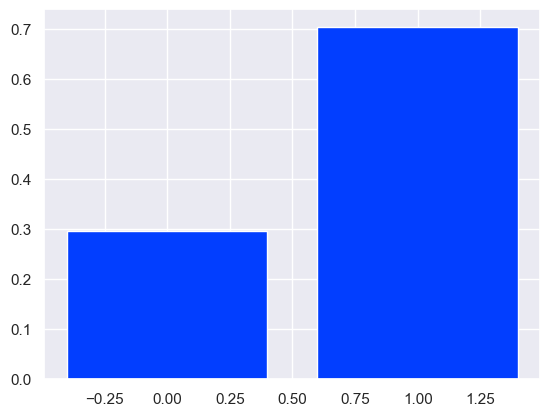

In [9]:
counter = Counter(train_data)
plt.bar(counter.keys(), list(map(lambda a: a / train_size, counter.values())))

## 1) Frequentist's approach

### 1.1) Bernoulli distribution function

write the function 'bern' that outputs the probability density function value of a bernoulli random variable 'x' and paramater 'mu' (see slide 7 in lecture 5).

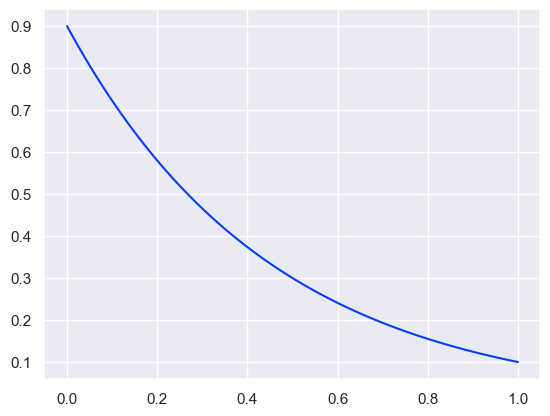

In [ ]:
def bern(x, mu):
    pass

### 1.2) Maximum Likelihood

write the function mu_maximum_likelihood_bern that takes data points train_data and should return the Maximum Likelihood estimate of the parameter 'mu' of the Bernoulli distribution (slide 9 of lecture 5). Is your estimate of 'mu' close to the theoretical value? Also, convince yourself that the 'train_data' that you generated above does belong to Bernoulli distribution!

In [5]:
def mu_maximum_likelihood_bern(train_data):
    pass
    # Expected: mu_ml ≈ 0.70 (close to the true heads probability of 0.7)

mu_ml = mu_maximum_likelihood_bern(train_data)

### 1.3) Display distribution

The function below plots the probability density (or mass) function of a Bernoulli random variable. Why is this function discrete?

In [6]:
def display_bernoulli(mu, color='b'):

    #xs = np.linspace(0., 1., 100)
    ys = list(map(
        lambda x: bern(x, mu),
        [0,1]
    ))

    plt.bar([0,1],ys)

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

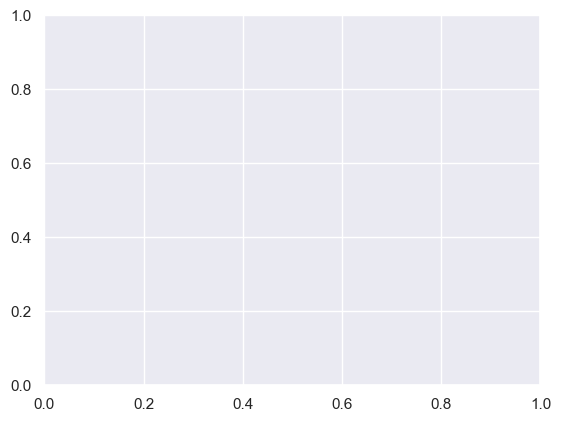

In [7]:
display_bernoulli(mu_ml)

## 2) Bayesian approach

### 2.1) Binomial distribution

Write a function that gives the value of probability density function for Binomial random variable with input parameters `m`, `N` and `mu`. Note that `m` denotes the number of successes in `N` Bernoulli trials or experiments and represents a binomial random variable. Returns: a float, the probability of exactly `m` successes in `N` trials with success probability `mu`.

In [ ]:
def binomial(m, N, mu):
    pass

### 2.2) Display Binomial distribution for different m

In [ ]:
def display_binomial(N, mu):
    xs = list(range(N + 1))  # support of the binomial: m = 0, 1, ..., N
    ys = list(map(
        lambda m: binomial(m, N, mu),
        xs
    ))
    
    plt.bar(xs, ys)
    plt.xlabel('m')

In [ ]:
display_binomial(10, 0.25)

### 2.3) Bayesian estimate (posterior mean)

Write a function `mu_maximum_posterior_bern` which takes parameters `m`, `N`, `a`, `b` and should return the **posterior mean estimate (MMSE)** of the parameter `mu` of the Bernoulli distribution (see slide 18 in Lecture 5). Compare this estimate with that obtained earlier in section 1.2 using the maximum likelihood estimator. How do the two estimators compare for large values of `N`?

Note: slide 18 gives the **mean** of the posterior (the MMSE estimator), which equals `(m+a)/(N+a+b)`. The mode of the posterior (MAP estimator) equals `(m+a−1)/(N+a+b−2)` and is discussed in PRML §2.1.1.

In [ ]:
def mu_maximum_posterior_bern(m, N, a, b):
    pass
    # Expected: ~0.7045 when called as mu_maximum_posterior_bern(sum(train_data), train_size, 0.1, 0.1)

In [ ]:
print(mu_maximum_posterior_bern(sum(train_data), train_size, 0.1, 0.1))

## 3) Multinomial variables

### 3.1) Generate data

generate samples of the multinomial random variable using 1-of-K scheme (see Lecture 5, slide 21). While the code is provided here, it is highly recommended to understand how the function has been implemented.

In [ ]:
np.random.seed(26)

def generate_multinomial_data(size, probabilities):
    numbers = np.random.choice(len(probabilities), size=size, replace=True, p=probabilities)
    
    result = np.zeros((numbers.size, len(probabilities)))
    result[np.arange(numbers.size), numbers] = 1
    return result
    
probabilities=[0.5, 0.1, 0.2, 0.1, 0.1]
multinomial_data = generate_multinomial_data(100, probabilities)
multinomial_data

### 3.2) Frequentist's approach

#### 3.2.1) Multinomial distribution function

Write a function bern_multi(xs, mus) that computes the probability of a single multinomial outcome.

xs: a one-hot encoded vector of length K, representing the observed outcome (which category occurred).
Example: [0,1,0,0] means category 2 was observed.

mus: probability vector of length K, where each entry is the probability of a category and all entries sum to 1.
Example: [0.2, 0.5, 0.3].

(see Lecture 5, slide 21)

In [ ]:
def bern_multi(xs, mus):
    pass

#### 3.2.2) Maximum likelihood

`mu_maximum_likelihood_multinomial_bern' takes multinomial data points, 'multinomial_data', and return Maximum Likelihood estimate of the parameters 'mus' of the Multinomial distribution (See slide 23 in Lecture 5). Print the estimated parameter values and compare those with the actual values. If they are different, how could you bring them closer?

In [ ]:
def mu_maximum_likelihood_multinomial_bern(multinomial_data):
    pass
    # Expected: approximately [0.46, 0.10, 0.23, 0.06, 0.15]

multi_mu_ml = mu_maximum_likelihood_multinomial_bern(multinomial_data)
multi_mu_ml

## 4) Gaussian distribution

### 4.1) Multivariate Gaussian Distribution Function

Write a function multi_gaussian(x, mean, covariance) that returns the probability density of the Gaussian distribution.

x: data point (scalar or vector)

mean: mean (scalar for 1D, vector for multivariate)

covariance: variance (1D) or covariance matrix (multivariate)

You may either:

Use the built-in method scipy.stats.multivariate_normal.pdf, or

Implement the formula in Lecture 6, slide 6 from scratch.

In [ ]:
def multi_gaussian(x, mean, covariance):
    pass

### 4.2) Generate data

The function below generates 'size' number of random samples from multivariate Gaussian distribution with a specified mean and covariance.

In [ ]:
def generate_multi_gaussian_data(size, mean, covariance):
    return np.array(multivariate_normal(mean=mean, cov=covariance).rvs(size=size, random_state=26))

target_mean = [1.7, -4]
target_cov = [[1, 0.1], [0.1, 1]]
multi_gaussian_data = generate_multi_gaussian_data(50, target_mean, target_cov)

### 4.3) Display data

See the output of the code below and understand the Gaussian contour plots. What do the smaller contours (in the center) represent in that figure? Where do the majority of the data points (blue dots) lie and why? 

In [ ]:
plt.plot(multi_gaussian_data[:, 0], multi_gaussian_data[:, 1], '.')

def display_gaussian_contour(data, mean, covariance, cmap='summer'):

    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    plt.contour(x, y, multivariate_normal(mean, covariance).pdf(pos), cmap=cmap)

display_gaussian_contour(multi_gaussian_data, target_mean, target_cov)

### 4.4) Parameter Estimation using Frequentist's approach

#### 4.4.1) Maximum likelihood

write the `multi_gaussian_mu_maximum_likelihood` function that takes Gaussian distributed data points `multi_gaussian_data` and should return Maximum Likelihood estimate of the mean of Multivariate Gaussian distribution (Slide 10 of lecture 6).

In [ ]:
def multi_gaussian_mu_maximum_likelihood(multi_gaussian_data):
    pass
    # Expected: approximately [ 1.64, -4.14]

g_mu_ml = multi_gaussian_mu_maximum_likelihood(multi_gaussian_data)
g_mu_ml

Write the function `multi_gaussian_covariance_maximum_likelihood` that takes Gaussian data points `multi_gaussian_data` and Maximum Likelihood estimate for `mu` (`g_mu_ml`) and should return Maximum Likelihood estimate of the covariance matrix of that distribution (slide 12 of lecture 6).

In [ ]:
def multi_gaussian_covariance_maximum_likelihood(multi_gaussian_data, g_mu_ml):
    pass
    # Expected: approximately [[0.831, -0.181], [-0.181, 0.955]] (MLE divides by N; see Lecture 6 slide 13 for unbiased version)

g_cov_ml = multi_gaussian_covariance_maximum_likelihood(multi_gaussian_data, g_mu_ml)
g_cov_ml

#### 4.4.2) Display distribution

Displaying and comparing between the estimated distribution and the true distribution. Should and Do they appear close together? 

In [ ]:
display_gaussian_contour(multi_gaussian_data, g_mu_ml, g_cov_ml, cmap='spring')
display_gaussian_contour(multi_gaussian_data, target_mean, target_cov, cmap='summer')

### 4.5) Parameter Estimation using Bayesian approach

Here, we will implement Gaussian parameter estimation methods using the Bayesian approach. The generated Gaussian data points will be univariate in this case.  

#### 4.5.1) Generate data

Generate 50 samples of univariate Gaussian data with mean=0.8 and variance=0.1

In [ ]:
def generate_gaussian_data(size, mean, variance):
    return np.array(norm(mean, sqrt(variance)).rvs(size=size, random_state=26))

g_mean = 0.8
g_variance = 0.1
gaussian_data = generate_gaussian_data(50, g_mean, g_variance)

plt.scatter(gaussian_data, [0] * len(gaussian_data), alpha=0.5)

#### 4.5.2) Estimating mean distribution when the variance is known

write the function `multi_gaussian_mu_maximum_posterior` that takes data points `gaussian_data`, prior mean `mu0` and prior variance `variance0`, actual variance of the distribution, `variance`, and should return the parameters (mean and variance) of the posterior distribution of the mean (see the last 2 equations in slide 15 of lecture 6). See PRML section 2.3.6 for details.

In [ ]:
def multi_gaussian_mu_maximum_posterior(gaussian_data, mu0, variance0, variance):
    pass
    # Expected: approximately (0.787, 0.00196) for gaussian_data with mu0=0, variance0=g_variance, variance=g_variance

g_mu_map, g_mu_var_map = multi_gaussian_mu_maximum_posterior(gaussian_data, 0, g_variance, g_variance)
g_mu_map, g_mu_var_map

#### 4.5.3) Display mean estimation for different values of N

Looking at the plots below, why does the mean distribution gets more and more concentrated around true value as the number of samples increase? What benefits this Bayesian approach offers over maximum likelihood approach?

In [ ]:
def display_mu_map(gaussian_data, mu0, variance0, variance):
    g_mu_map, g_mu_var_map = multi_gaussian_mu_maximum_posterior(gaussian_data, mu0, variance0, variance)
    x = np.linspace(-1, 1, 100)
    y = norm(g_mu_map, sqrt(g_mu_var_map)).pdf(x)
    plt.plot(x, y, label='N=' + str(len(gaussian_data)))
    plt.legend()

display_mu_map(gaussian_data[:0], 0, g_variance, g_variance)
display_mu_map(gaussian_data[:1], 0, g_variance, g_variance)
display_mu_map(gaussian_data[:10], 0, g_variance, g_variance)
display_mu_map(gaussian_data, 0, g_variance, g_variance)